# Quantum Teleportation
**Notebook:** Complete 3-qubit protocol — transmits an arbitrary qubit state using a Bell pair and 2 classical bits

## Overview

**Quantum teleportation** transmits an arbitrary qubit state $|\psi\rangle$ from Alice to Bob
using:
- 1 pre-shared **Bell pair** (entangled qubit pair)
- 2 **classical bits** of communication

No quantum channel is needed after the Bell pair is distributed. The state is **not cloned**
(no-cloning theorem is respected) — Alice's qubit is destroyed in the process.

### Protocol (4 steps)
| Step | Action | Description |
|------|--------|-------------|
| 1 | Prepare $\|\psi\rangle$ | Alice encodes the state to teleport on $q_0$ |
| 2 | Bell pair | Entangle $q_1$ (Alice) and $q_2$ (Bob) via $H + \text{CNOT}$ |
| 3 | Bell measurement | Alice measures $q_0, q_1$ jointly → 2 classical bits |
| 4 | Correction | Bob applies $X$ and/or $Z$ based on Alice's bits |

### Why it works
The Bell measurement collapses the joint state into one of 4 Bell states.
Bob's qubit is already in a state related to $|\psi\rangle$ — he just needs to apply
the right Pauli correction (told to him via classical channel) to recover $|\psi\rangle$ exactly.

### Verification
Bob should measure $|0\rangle$ with probability $\cos^2(\theta/2)$ and $|1\rangle$ with $\sin^2(\theta/2)$,
matching the original state $\cos(\theta/2)|0\rangle + \sin(\theta/2)|1\rangle$.

In [29]:
# ── Imports ──────────────────────────────────────────────────────────────────
# Standard environment fixes (prevents OpenMP conflicts on some systems)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'   # allow duplicate OpenMP libs
os.environ['OMP_NUM_THREADS'] = '1'            # single-threaded OpenMP avoids crashes

# Load API tokens from a .env file (e.g., IBM_QUANTUM_TOKEN=...)
from dotenv import load_dotenv
load_dotenv()

# Core Qiskit circuit-building components
import qiskit as qk
from qiskit import QuantumCircuit
import pylatexenc                               # required for circuit diagram rendering

In [30]:

from qiskit import QuantumRegister
from qiskit import ClassicalRegister, transpile

import numpy as np
from math import pi

# Local simulator backend (no account needed)
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [31]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from collections import Counter

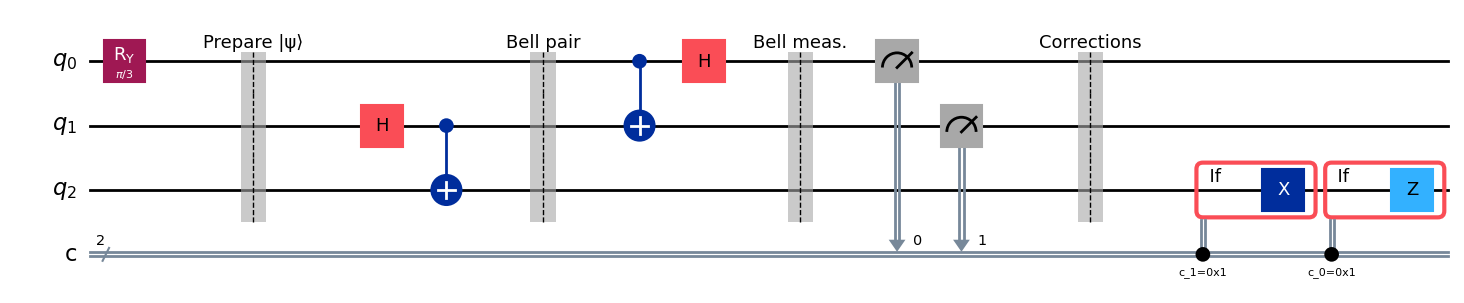

In [32]:
# Quantum Teleportation Protocol
# Teleports an arbitrary qubit state |ψ⟩ from Alice to Bob using a shared
# Bell pair and 2 classical bits of communication.
#
# Registers:
#   q[0] = message qubit (Alice) — holds the state |ψ⟩ = cos(θ/2)|0⟩ + sin(θ/2)|1⟩
#   q[1] = Alice's half of the Bell pair (entangled with Bob)
#   q[2] = Bob's half of the Bell pair (remote end)
#   c[0], c[1] = classical bits sent from Alice to Bob over a classical channel

theta = pi / 3   # message state parameter — change to teleport a different state

qr = QuantumRegister(3, 'q')
cr = ClassicalRegister(2, 'c')
qc = QuantumCircuit(qr, cr)

# --- Step 1: Prepare message state |ψ⟩ on q[0] ---
# RY(θ)|0⟩ = cos(θ/2)|0⟩ + sin(θ/2)|1⟩  (real-amplitude state on the Bloch sphere)
qc.ry(theta, qr[0])
qc.barrier(label='Prepare |ψ⟩')

# --- Step 2: Create Bell pair |Φ+⟩ between q[1] (Alice) and q[2] (Bob) ---
# H on q[1]: |0⟩ → (|0⟩+|1⟩)/√2  (superposition)
qc.h(qr[1])
# CNOT q[1]→q[2]: entangles the pair → (|00⟩+|11⟩)/√2  (Bell state |Φ+⟩)
qc.cx(qr[1], qr[2])
qc.barrier(label='Bell pair')

# --- Step 3: Bell measurement on Alice's qubits q[0] and q[1] ---
# CNOT q[0]→q[1]: entangles message qubit with Alice's Bell qubit
qc.cx(qr[0], qr[1])
# H on q[0]: rotates into the Bell basis so that measurement gives one of 4 outcomes
qc.h(qr[0])
qc.barrier(label='Bell meas.')
qc.measure(qr[0], cr[0])   # c[0] ← measurement of q[0] (controls Bob's Z correction)
qc.measure(qr[1], cr[1])   # c[1] ← measurement of q[1] (controls Bob's X correction)
qc.barrier(label='Corrections')

# --- Step 4: Bob applies Pauli corrections based on Alice's 2 classical bits ---
# If c[1]=1: Bob applies X (bit-flip) to recover the correct |0⟩/|1⟩ component
with qc.if_test((cr[1], 1)):
    qc.x(qr[2])
# If c[0]=1: Bob applies Z (phase-flip) to recover the correct phase
with qc.if_test((cr[0], 1)):
    qc.z(qr[2])
# After corrections, q[2] is guaranteed to be in state |ψ⟩ = cos(θ/2)|0⟩ + sin(θ/2)|1⟩

qc.draw('mpl')

Measurement counts  (format: 'bob c[0]c[1]'):
{'0 10': 394, '0 11': 405, '0 01': 406, '1 10': 112, '0 00': 370, '1 11': 100, '1 00': 134, '1 01': 127}


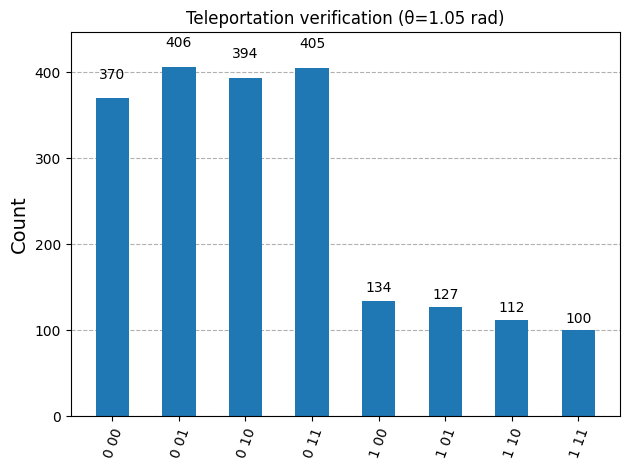

In [33]:
# --- Verification circuit ---
# Rebuilds the full protocol and adds a final measurement on Bob's qubit (q[2]).
# We use a separate circuit so we can measure Bob's qubit without disturbing the
# display-only circuit above.
qr2 = QuantumRegister(3, 'q')
cr2 = ClassicalRegister(2, 'c')       # Alice's 2 classical bits
cr_bob = ClassicalRegister(1, 'bob')  # Bob's measurement result
qc_verify = QuantumCircuit(qr2, cr2, cr_bob)

# Step 1: prepare the same message state
qc_verify.ry(theta, qr2[0])

# Step 2: create Bell pair
qc_verify.h(qr2[1])
qc_verify.cx(qr2[1], qr2[2])

# Step 3: Bell measurement
qc_verify.cx(qr2[0], qr2[1])
qc_verify.h(qr2[0])
qc_verify.measure(qr2[0], cr2[0])   # c[0]: controls Z correction
qc_verify.measure(qr2[1], cr2[1])   # c[1]: controls X correction

# Step 4: conditional Pauli corrections on Bob's qubit
with qc_verify.if_test((cr2[1], 1)):
    qc_verify.x(qr2[2])   # X correction if Alice's q[1] measured |1⟩
with qc_verify.if_test((cr2[0], 1)):
    qc_verify.z(qr2[2])   # Z correction if Alice's q[0] measured |1⟩

# Measure Bob's qubit — should reproduce the statistics of |ψ⟩
qc_verify.measure(qr2[2], cr_bob[0])

backend = AerSimulator()
result = backend.run(transpile(qc_verify, backend), shots=2048).result()
counts = result.get_counts()
print("Measurement counts  (format: 'bob c[0]c[1]'):")
print(counts)
plot_histogram(counts, title=f"Teleportation verification (θ={theta:.2f} rad)")

# Let's check newer API

In [34]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from collections import Counter

service = QiskitRuntimeService(channel='ibm_cloud', token=os.environ['IBM_QUANTUM_TOKEN'])
#backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
backend = AerSimulator()

sampler = Sampler(backend)
job = sampler.run([transpile(qc_verify, backend)], shots=1024)

data = job.result()[0].data

# Get register names via vars() — works across qiskit-ibm-runtime versions
fields = list(vars(data).keys())
print("Registers:", fields)

# Combine per-shot bitstrings across all classical registers (correlated joint counts)
bitstring_lists = [getattr(data, f).get_bitstrings() for f in fields]
resultSim_counts = dict(Counter(' '.join(bits) for bits in zip(*bitstring_lists)))
print(resultSim_counts)

qiskit_runtime_service._discover_account:WARNING:2026-03-15 21:55:13,297: Loading account with the given token. A saved account will not be used.


qiskit_runtime_service.__init__:WARNING:2026-03-15 21:55:25,072: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Registers: ['c', 'bob']
{'11 0': 166, '10 1': 70, '00 1': 70, '01 0': 210, '00 0': 206, '10 0': 185, '11 1': 57, '01 1': 60}


In [35]:
# Theoretical check: Bob should measure |0⟩ with prob cos²(θ/2), |1⟩ with sin²(θ/2)
p0_expected = np.cos(theta / 2) ** 2
p1_expected = np.sin(theta / 2) ** 2

# Extract Bob's qubit marginal from the full count dict
# Key format: "bob alice_c1 alice_c0" (rightmost = cr2, leftmost = cr_bob)
bob_0 = sum(v for k, v in resultSim_counts.items() if k.split(' ')[-1] == '0')
bob_1 = sum(v for k, v in resultSim_counts.items() if k.split(' ')[-1] == '1')
total = bob_0 + bob_1

print(f"Expected:  P(|0⟩) = {p0_expected:.3f},  P(|1⟩) = {p1_expected:.3f}")
print(f"Measured:  P(|0⟩) = {bob_0/total:.3f},  P(|1⟩) = {bob_1/total:.3f}")
success = abs(bob_0 / total - p0_expected) < 0.05
print(f"\nTeleportation {'SUCCESSFUL ✓' if success else 'check failed (try more shots)'}")

Expected:  P(|0⟩) = 0.750,  P(|1⟩) = 0.250
Measured:  P(|0⟩) = 0.749,  P(|1⟩) = 0.251

Teleportation SUCCESSFUL ✓


## Now let's try to run on IMB cloud

In [36]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from collections import Counter

service = QiskitRuntimeService(channel='ibm_cloud', token=os.environ['IBM_QUANTUM_TOKEN'])
backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
sampler = Sampler(backend_real)

job = sampler.run([transpile(qc_verify, backend_real)], shots=1024)

data = job.result()[0].data


# Get register names via vars() — works across qiskit-ibm-runtime versions
fields = list(vars(data).keys())
print("Registers:", fields)

# Combine per-shot bitstrings across all classical registers (correlated joint counts)
bitstring_lists = [getattr(data, f).get_bitstrings() for f in fields]
resultExp_counts = dict(Counter(' '.join(bits) for bits in zip(*bitstring_lists)))
print(resultExp_counts)


qiskit_runtime_service._discover_account:WARNING:2026-03-15 21:55:25,608: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-15 21:55:34,142: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-15 21:55:34,938: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-15 21:55:40,043: Using instance: open-instance, plan: open


Registers: ['c', 'bob']
{'11 1': 54, '01 0': 186, '11 0': 191, '10 1': 92, '10 0': 185, '00 0': 182, '00 1': 65, '01 1': 69}


In [37]:

# Theoretical check: Bob should measure |0⟩ with prob cos²(θ/2), |1⟩ with sin²(θ/2)
p0_expected = np.cos(theta / 2) ** 2
p1_expected = np.sin(theta / 2) ** 2

# Extract Bob's qubit marginal from the full count dict
# Key format: "bob alice_c1 alice_c0" (rightmost = cr2, leftmost = cr_bob)
bob_0 = sum(v for k, v in resultSim_counts.items() if k.split(' ')[-1] == '0')
bob_1 = sum(v for k, v in resultSim_counts.items() if k.split(' ')[-1] == '1')
total = bob_0 + bob_1

print(f"Expected:  P(|0⟩) = {p0_expected:.3f},  P(|1⟩) = {p1_expected:.3f}")
print(f"Measured:  P(|0⟩) = {bob_0/total:.3f},  P(|1⟩) = {bob_1/total:.3f}")
success = abs(bob_0 / total - p0_expected) < 0.05
print(f"\nTeleportation {'SUCCESSFUL ✓' if success else 'check failed (try more shots)'}")

Expected:  P(|0⟩) = 0.750,  P(|1⟩) = 0.250
Measured:  P(|0⟩) = 0.749,  P(|1⟩) = 0.251

Teleportation SUCCESSFUL ✓


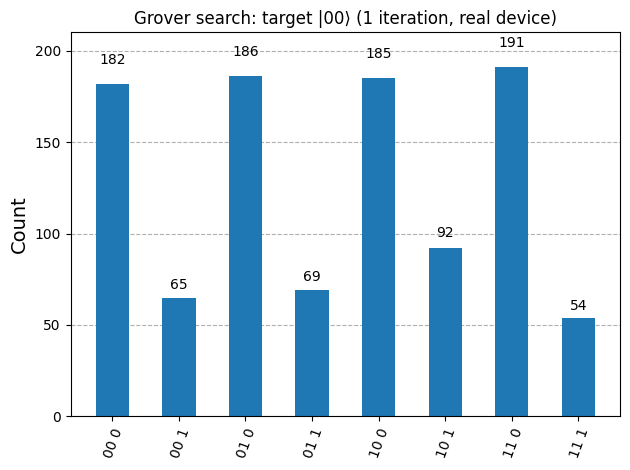

In [38]:
plot_histogram(resultExp_counts, title="Grover search: target |00⟩ (1 iteration, real device)")